## Building Basic Chatbot using Langgraph (Graph API)

In [1]:
import os
from dotenv import load_dotenv

from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [2]:
load_dotenv()

True

In [3]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model
llm=ChatGroq(model="llama-3.1-8b-instant",api_key=os.getenv("GROQ_API"))

In [4]:
llm2=init_chat_model("groq:llama-3.1-8b-instant", api_key=os.getenv("GROQ_API"))

In [5]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

graph_builder=StateGraph(State)

In [6]:
def chatbot_node(state:State):
    return{"messages":[llm2.invoke(state["messages"])]}

In [7]:
# building state graph

# adding nodes
graph_builder.add_node("llmbasicbot",chatbot_node)

# adding edges
graph_builder.add_edge(START,"llmbasicbot")
graph_builder.add_edge("llmbasicbot",END)

# compiling graph

graph=graph_builder.compile()



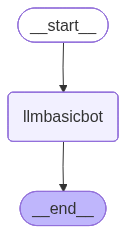

In [8]:
## visualising graph 
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Error Occured : {e}")

In [9]:
responses=graph.invoke({"messages":"Hi"})

In [10]:
responses=graph.invoke({"messages":"what is AI"})

In [11]:
responses["messages"][-1]

AIMessage(content='Artificial Intelligence (AI) refers to the simulation of human intelligence in machines that are programmed to think and learn like humans. The term can also be applied to any machine that exhibits traits associated with a human mind such as learning and problem-solving.\n\nAI technology is based on the principle of creating algorithms that can process data, identify patterns, and make decisions with minimal human intervention. This can be achieved through various techniques such as machine learning, deep learning, and neural networks.\n\nAI systems can be categorized into two main types:\n\n1. **Narrow or Weak AI**: This type of AI is designed to perform a specific task, such as image recognition, speech recognition, or playing a particular game. Narrow AI systems are trained on large datasets and can learn from experience, but they are not capable of general reasoning or problem-solving outside of their specific domain.\n\n2. **General or Strong AI**: This type of 

In [12]:
for events in graph.stream({"messages":"Hey! How are you?"}):
    print (events)


{'llmbasicbot': {'messages': [AIMessage(content="I'm doing well, thank you for asking. I'm a large language model, so I don't have emotions or feelings like humans do, but I'm functioning properly and ready to help with any questions or tasks you may have. How about you? Is there something specific you'd like to talk about or ask?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 65, 'prompt_tokens': 41, 'total_tokens': 106, 'completion_time': 0.07458625, 'completion_tokens_details': None, 'prompt_time': 0.002618628, 'prompt_tokens_details': None, 'queue_time': 0.005726268, 'total_time': 0.077204878}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_e2c608b1d6', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eeb22-4268-7142-a09c-e9712f659e4b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 65, 'total_tokens': 106})]}}


In [13]:
for events in graph.stream({"messages":"Hey! How are you?"}):
    for values in events.values():
        print (values)


{'messages': [AIMessage(content="I'm doing well, thank you for asking. I'm a large language model, so I don't have feelings in the way humans do, but I'm functioning properly and ready to assist you with any questions or tasks you may have. How about you? How's your day going so far?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 61, 'prompt_tokens': 41, 'total_tokens': 102, 'completion_time': 0.068242469, 'completion_tokens_details': None, 'prompt_time': 0.00302936, 'prompt_tokens_details': None, 'queue_time': 0.005789333, 'total_time': 0.071271829}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_020e283281', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eeb22-464d-7af2-aeef-68a1e8a747b4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 61, 'total_tokens': 102})]}


In [14]:
for events in graph.stream({"messages":"Hey! How are you?"}):
    for values in events.values():
        print (values["messages"][-1].content)

I'm doing well, thank you for asking. I'm a large language model, so I don't have emotions or feelings like humans do, but I'm always happy to chat with you and help with any questions or topics you'd like to discuss. How about you? How's your day going so far?


In [15]:
for events in graph.stream({"messages":"Hey! Could you please provide me live news about FIFA world cup match"}):
    for values in events.values():
        print (values["messages"][-1].content)

I'm not capable of providing live news updates in real-time. However, I can suggest some reliable sources that provide live news and updates about the FIFA World Cup:

1. **FIFA Official Website**: You can visit the official FIFA website (fifa.com) for the latest news, scores, and updates from the World Cup.
2. **BBC Sports**: BBC Sports provides live coverage of the World Cup, including news, scores, and expert analysis. You can visit their website (bbc.com/sport) or tune in to their live coverage on TV or online.
3. **ESPN**: ESPN is another major sports network that provides live coverage of the World Cup. You can visit their website (espn.com) or tune in to their live coverage on TV or online.
4. **Al Jazeera**: Al Jazeera provides live coverage of the World Cup, including news, scores, and analysis. You can visit their website (aljazeera.com) or tune in to their live coverage on TV or online.
5. **Sky Sports**: Sky Sports provides live coverage of the World Cup, including news, sc

In [16]:
##Adding External Tools

## Chatbot with tools

from langchain_tavily import TavilySearch

tool= TavilySearch(max_results=2,tavily_api_key=os.getenv("TAVILY_API_KEY"))
tool.invoke("What is Langchain and Langgraph")

{'query': 'What is Langchain and Langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.geeksforgeeks.org/artificial-intelligence/langchain-vs-langgraph',
   'title': 'LangChain vs. LangGraph - GeeksforGeeks',
   'content': 'LangChain and LangGraph are tools that help build AI workflows. LangChain works in a step by step way, while LangGraph allows more flexible paths. LangChain is a framework designed to connect large language models into structured workflows enabling multi step reasoning and automation. LangGraph is a framework that organizes large language models into graph based workflows enabling flexible and parallel multi step reasoning. | Goal | Connects steps in order for structured, multi step reasoning | Builds flexible workflows using graph style task flow |. | Flow Type | Works in a straight, step by step manner | Supports parallel, conditional and adaptive paths |. | Ease of Implementation | Simple to use for straightfo

In [17]:
## Custom Function

def multiply(a:int,b:int)->int:
    """
    Multiply a and b 
    Args:
    a(first int)
    b(second int)

    Returns:
        int: output int
    """
    return a*b

In [18]:
tools=[tool,multiply]

In [19]:
llm_with_tools=llm.bind_tools(tools)

In [20]:
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.7', 'langchain': '1.3.9'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x11252d010>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x11252da90>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for

In [21]:
## Stategraph

from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Node definition
def tool_calling_llm(state:State):
    return{"messages":[llm_with_tools.invoke(state["messages"])]}

## Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools=tools))

## Add edges

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",tools_condition)
## IF the input from llm requires tool calling then it will go to tools node else shall just go to END node
builder.add_edge("tools",END)

graph=builder.compile()




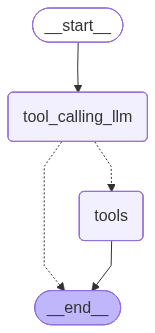

In [22]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [23]:
response=graph.invoke({"messages":"What is the recent FIFA world cup 2026 match score."})

In [24]:
response["messages"][-1].content

'{"query": "FIFA world cup 2026 match score", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.telecomasia.net/news/football/2026-fifa-world-cup-top-scorers-as-of-june-21-2026/", "title": "2026 FIFA World Cup Top Scorers as of June 21, 2026 - Telecom Asia Sport", "score": 0.89567816, "published_date": "Sun, 21 Jun 2026 08:15:23 GMT", "content": "# 2026 FIFA World Cup Top Scorers as of June 21, 2026\\n\\nMarina Magomedova\\n\\nOn the night of June 20-21, four matches of the 2026 FIFA World Cup group stage were played in Groups E and F, taking place in the United States, Canada, and Mexico.\\n\\nOn Matchday 2, June 20-21, the results were as follows: Germany defeated Côte d\'Ivoire (2-1), the Netherlands defeated Sweden (5-1), Japan crushed Tunisia (4-0), and Ecuador drew with Curaçao (0-0).\\n\\nCurrently, Argentina\'s Lionel Messi and Canada\'s Jonathan David lead the scoring race, with three goals each. Based on additional indicators, the eig

In [25]:
for message in response["messages"]:
    print(message.pretty_print())

================================ Human Message =================================

What is the recent FIFA world cup 2026 match score.
None
================================== Ai Message ==================================
Tool Calls:
  tavily_search (kh1hbb1vq)
 Call ID: kh1hbb1vq
  Args:
    query: FIFA world cup 2026 match score
    search_depth: advanced
    time_range: day
    topic: news
None
================================= Tool Message =================================
Name: tavily_search

{"query": "FIFA world cup 2026 match score", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.telecomasia.net/news/football/2026-fifa-world-cup-top-scorers-as-of-june-21-2026/", "title": "2026 FIFA World Cup Top Scorers as of June 21, 2026 - Telecom Asia Sport", "score": 0.89567816, "published_date": "Sun, 21 Jun 2026 08:15:23 GMT", "content": "# 2026 FIFA World Cup Top Scorers as of June 21, 2026\n\nMarina Magomedova\n\nOn the night of June 20-21, fou

In [26]:
response=graph.invoke({"messages":"What is 104587695 multiplied by 95485."})

In [27]:
for response in response["messages"]:
    response.pretty_print()

================================ Human Message =================================

What is 104587695 multiplied by 95485.
================================== Ai Message ==================================
Tool Calls:
  multiply (085p0fr56)
 Call ID: 085p0fr56
  Args:
    a: 104587695
    b: 95485
================================= Tool Message =================================
Name: multiply

9986556057075


In [28]:
response=graph.invoke({"messages":"What is 104587695 multiplied by 95485. And also give me latest news for SpaceX IPO in june 2026"})

In [29]:
for response in response["messages"]:
    response.pretty_print()

================================ Human Message =================================

What is 104587695 multiplied by 95485. And also give me latest news for SpaceX IPO in june 2026
================================== Ai Message ==================================
Tool Calls:
  multiply (wjsejwzmh)
 Call ID: wjsejwzmh
  Args:
    a: 104587695
    b: 95485
================================= Tool Message =================================
Name: multiply

9986556057075


In [30]:
def add(a: int, b: float)->float:
    """Adding a and b
    
    Args:
        a (first int)
        b (Second float)

    Returns:
        float: output float
    """
    return a+b

def divide(a: float, b: float)->float:
    """divide a by b
    
    Args:
        a (first float)
        b (Second float)

    Returns:
        float: output float
    """
    return a/b

In [31]:
tools2=[tool,multiply,add,divide]

In [32]:
llm_with_tools_updated=llm.bind_tools(tools=tools2)

In [33]:
## ReACT Agent architecture. Act, Observe and Reason.

## Stategraph

from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Node definition
def tool_calling_llm_updated(state:State):
    return{"messages":[llm_with_tools_updated.invoke(state["messages"])]}

## Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm_updated",tool_calling_llm_updated)
builder.add_node("tools",ToolNode(tools=tools))

## Add edges

builder.add_edge(START,"tool_calling_llm_updated")
builder.add_conditional_edges("tool_calling_llm_updated",tools_condition)
## IF the input from llm requires tool calling then it will go to tools node else shall just go to END node
builder.add_edge("tools","tool_calling_llm_updated")

graph=builder.compile()


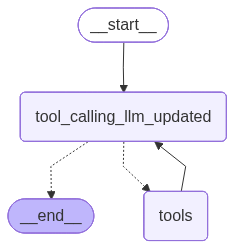

In [34]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [36]:
response=graph.invoke({"messages":"What is 104587695 multiplied by 95485. And also give me latest news for SpaceX IPO in june 2026. Could you please add 46 and 24, then divide the result by 4.0"})

KeyboardInterrupt: 

In [ ]:
for response in response["messages"]:
    response.pretty_print()

================================ Human Message =================================

What is 104587695 multiplied by 95485. And also give me latest news for SpaceX IPO in june 2026. Could you please add 46 and 24, then divide the result by 4.0
================================== Ai Message ==================================
Tool Calls:
  multiply (kkppbxdp4)
 Call ID: kkppbxdp4
  Args:
    a: 104587695
    b: 95485
  tavily_search (3bwwh9acr)
 Call ID: 3bwwh9acr
  Args:
    end_date: None
    query: SpaceX IPO news june 2026
    time_range: month
    topic: news
  add (k3n0mnbey)
 Call ID: k3n0mnbey
  Args:
    a: 46
    b: 24
  divide (mk2125624)
 Call ID: mk2125624
  Args:
    a: 70
    b: 4
================================= Tool Message =================================
Name: multiply

9986556057075
================================= Tool Message =================================
Name: tavily_search

{"query": "SpaceX IPO news june 2026", "follow_up_questions": null, "answer": null, "ima

## Adding Memory

In [37]:
response=graph.invoke({"messages":"Hi My name is Syed Noor"})

In [38]:
for response in response["messages"]:
    response.pretty_print()

================================ Human Message =================================

Hi My name is Syed Noor
================================== Ai Message ==================================

Nice to meet you, Syed Noor. How can I assist you today?


In [39]:
response=graph.invoke({"messages":"What is my name?"})

In [40]:
[response.pretty_print() for response in response["messages"]]


================================ Human Message =================================

What is my name?
================================== Ai Message ==================================

I don't have any information about your name. I'm a large language model, I don't have the ability to retain information about individual users or their personal details. If you'd like to chat about something, I'm here to help!


[None, None]

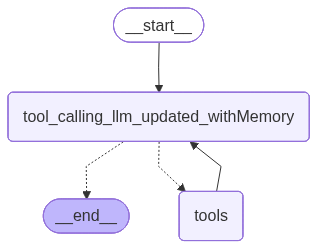

In [ ]:
## ReACT Agent architecture. Act, Observe and Reason.

## Stategraph

from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
# adding memory saver for past conversations
from langgraph.checkpoint.memory import MemorySaver

memory=MemorySaver()
# Node definition
def tool_calling_llm_updated_withMemory(state:State):
    return{"messages":[llm_with_tools_updated.invoke(state["messages"])]}

## Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm_updated_withMemory",tool_calling_llm_updated_withMemory)
builder.add_node("tools",ToolNode(tools=tools))

## Add edges

builder.add_edge(START,"tool_calling_llm_updated_withMemory")
builder.add_conditional_edges("tool_calling_llm_updated_withMemory",tools_condition)
## IF the input from llm requires tool calling then it will go to tools node else shall just go to END node
builder.add_edge("tools","tool_calling_llm_updated_withMemory")

graph=builder.compile(checkpointer=MemorySaver()) # saves memory


display(Image(graph.get_graph().draw_mermaid_png()))

In [45]:
config={"configurable":{"thread_id":"1"}}

response_with_memory=graph.invoke({"messages":"Hey I am Syed Noor Mujassum"},config=config)

response_with_memory

{'messages': [HumanMessage(content='Hey I am Syed Noor Mujassum', additional_kwargs={}, response_metadata={}, id='10079b88-94a2-4e94-aac5-2fcb1a21c916'),
  AIMessage(content='Nice to meet you, Syed Noor Mujassum. What brings you here today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 1872, 'total_tokens': 1892, 'completion_time': 0.031287109, 'completion_tokens_details': None, 'prompt_time': 0.138709314, 'prompt_tokens_details': None, 'queue_time': 0.037975223, 'total_time': 0.169996423}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_e2c608b1d6', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eeb2d-74a5-7db1-9a2e-0e2577434a33-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1872, 'output_tokens': 20, 'total_tokens': 1892}),
  HumanMessage(content='Hey I am Syed Noor Mujassum', additional_kwargs={}, response_metadata={}, i

In [46]:
response_with_memory["messages"][-1]

AIMessage(content='It seems like you introduced yourself again. Would you like to talk about something specific or ask a question?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 1911, 'total_tokens': 1933, 'completion_time': 0.03973948, 'completion_tokens_details': None, 'prompt_time': 0.187456379, 'prompt_tokens_details': None, 'queue_time': 0.016884029, 'total_time': 0.227195859}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_e2c608b1d6', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eeb2d-d7d4-7ba1-9dca-b4304b6e082d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1911, 'output_tokens': 22, 'total_tokens': 1933})

In [47]:
response_with_memory=graph.invoke({"messages":"Hey wcould you please tell me what 54 adding with 67. Also could you please tell me what is my name?"},config=config)

In [50]:
response_with_memory

{'messages': [HumanMessage(content='Hey I am Syed Noor Mujassum', additional_kwargs={}, response_metadata={}, id='10079b88-94a2-4e94-aac5-2fcb1a21c916'),
  AIMessage(content='Nice to meet you, Syed Noor Mujassum. What brings you here today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 1872, 'total_tokens': 1892, 'completion_time': 0.031287109, 'completion_tokens_details': None, 'prompt_time': 0.138709314, 'prompt_tokens_details': None, 'queue_time': 0.037975223, 'total_time': 0.169996423}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_e2c608b1d6', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eeb2d-74a5-7db1-9a2e-0e2577434a33-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1872, 'output_tokens': 20, 'total_tokens': 1892}),
  HumanMessage(content='Hey I am Syed Noor Mujassum', additional_kwargs={}, response_metadata={}, i

## Streaming
.stream() and .astream()

Updates: provides only latest AI message
Values: provides both AI and Human messgae

In [56]:
config={"configurable":{"thread_id":"2"}}

response_stream_updates=graph.stream({"messages":"Hey I am Syed Noor Mujassum"},config=config,stream_mode="updates")

[print (chunks)for chunks in response_stream_updates]

{'tool_calling_llm_updated_withMemory': {'messages': [AIMessage(content="It's nice to meet you, Syed Noor Mujassum. Is there something I can help you with today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 1915, 'total_tokens': 1941, 'completion_time': 0.035378902, 'completion_tokens_details': None, 'prompt_time': 0.111461361, 'prompt_tokens_details': None, 'queue_time': 0.007367631, 'total_time': 0.146840263}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_e2c608b1d6', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eeb3c-3d34-7eb2-81b2-5b6c2e0a53ae-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1915, 'output_tokens': 26, 'total_tokens': 1941})]}}


[None]

In [74]:
config={"configurable":{"thread_id":"3"}}

response_stream_values=graph.stream({"messages":"Hey I am Syed Noor Mujassum, I like football"},config=config,stream_mode="values")

[print(chunks)for chunks in response_stream_values]

{'messages': [HumanMessage(content='Hey I am Syed Noor Mujassum', additional_kwargs={}, response_metadata={}, id='92467df0-d74a-4532-9391-5413b4e917ec'), AIMessage(content='Nice to meet you, Syed Noor Mujassum. How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 1872, 'total_tokens': 1893, 'completion_time': 0.027217501, 'completion_tokens_details': None, 'prompt_time': 0.291012376, 'prompt_tokens_details': None, 'queue_time': 0.006940581, 'total_time': 0.318229877}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_e2c608b1d6', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eeb3b-6d58-74e1-aa65-fe44174c2d4f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1872, 'output_tokens': 21, 'total_tokens': 1893}), HumanMessage(content='Hey I am Syed Noor Mujassum', additional_kwargs={}, response_metadata={}, id='6

[None, None, None, None]

In [75]:
config={"configurable":{"thread_id":"5"}}
response_astream=graph.astream_events({"messages":["Hey! I am Syed Noor Looking for Fat loss of next year"]}, config=config,version="v2")

In [76]:

import nest_asyncio

# Allow nested event loops in Jupyter
nest_asyncio.apply()

# Now run the async events
async def run_events():
    async for event in response_astream:
        print(event)

import asyncio
await run_events()

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hey! I am Syed Noor Looking for Fat loss of next year']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019eeb47-0f28-7211-8130-40f0f99c8463', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hey! I am Syed Noor Looking for Fat loss of next year', additional_kwargs={}, response_metadata={}, id='97f8f726-5e9b-434f-9646-4af6c4aed2c1'), HumanMessage(content='Hey! I am Syed Noor Looking for Fat loss of next year', additional_kwargs={}, response_metadata={}, id='d1d6d3c6-6051-42f9-b48b-942971408c04'), HumanMessage(content='Hey! I am Syed Noor Looking for Fat loss of next year', additional_kwargs={}, response_metadata={}, id='d39a6ced-9bf0-46fb-aad9-b4492bbff250')]}}, 'name': 'tool_calling_llm_updated_withMemory', 'tags': ['graph:step:6'], 'run_id': '019eeb47-0f2b-7c73-8b87-f82c6fc00f67', 'metadata': {'thread_id': '5', '

APIError: Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.